
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fourmodern/molecular_docking_tutorial/blob/main/practical_docking/03_SAR_Matrix.ipynb)

# SAR Matrix — R1 × R2 도킹 스코어 매트릭스

## 목적

하나의 backbone scaffold에서 **R1, R2 치환체를 체계적으로 변화**시켜,
어떤 조합이 가장 좋은 결합력을 보이는지 **매트릭스 형태의 SAR 테이블**을 생성합니다.

## 이론적 배경

### SAR (Structure-Activity Relationship)
분자 구조의 변화가 생물학적 활성에 미치는 영향을 분석하는 약물화학의 핵심 방법론입니다.

### R-group Decomposition
Core scaffold를 고정하고 치환체(R-group)만 변화시켜 효과를 측정합니다:
- **단일 효과**: 각 R-group이 독립적으로 미치는 영향
- **조합 효과**: R1×R2 조합이 예상(단순 합산)과 다른지 → 시너지/길항

### Additivity 원리
두 치환체의 효과가 독립적이면: Score(R1,R2) ≈ baseline + effect(R1) + effect(R2)
이 예측과 실제값의 차이(residual)가 SAR의 핵심 정보입니다.

## 워크플로우
1. 타겟 PDB + Backbone + R1/R2 정의
2. Docking Box 설정 + 3D 확인
3. 전체 R1×R2 조합 도킹
4. SAR Matrix 히트맵
5. R-group 효과 분석 + Additivity 체크
6. 내보내기


## 0. 환경 설정


### 환경 설치

필요한 패키지를 설치합니다.


In [1]:
#@title 환경 설치 (처음 1회) {display-mode: "form"}
import subprocess, sys, os

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + list(pkgs))

pip_install('rdkit', 'gemmi', 'openbabel-wheel')
pip_install('pdbfixer', 'openmm')
pip_install('py3Dmol', 'MDAnalysis')
pip_install('seaborn', 'pandas', 'matplotlib', 'requests')
try: pip_install('pymol-open-source')
except: pass

BIN_DIR = '/opt/bin' if os.path.exists('/opt/bin/smina') else '/content/bin'
os.makedirs(BIN_DIR, exist_ok=True)
smina_path = os.path.join(BIN_DIR, 'smina')
if not os.path.exists(smina_path):
    import stat, urllib.request
    print('Downloading smina...')
    urllib.request.urlretrieve(
        'https://sourceforge.net/projects/smina/files/smina.static/download', smina_path)
    os.chmod(smina_path, os.stat(smina_path).st_mode | stat.S_IEXEC | stat.S_IXGRP | stat.S_IXOTH)
os.environ['PATH'] = BIN_DIR + ':' + os.environ['PATH']
print('Done.')


Done.


### 라이브러리 로드


In [2]:
#@title 라이브러리 로드 {display-mode: "form"}
import warnings; warnings.filterwarnings('ignore')
import os, subprocess, urllib.request, time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import py3Dmol
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, Descriptors
from openbabel import pybel
from pdbfixer import PDBFixer
from openmm.app import PDBFile
import MDAnalysis as mda

BIN_DIR = '/opt/bin' if os.path.exists('/opt/bin/smina') else '/content/bin'
WORK_DIR = '/content/sar_matrix' if os.path.exists('/content') else os.path.join(os.path.expanduser('~'), 'sar_matrix')
os.makedirs(WORK_DIR, exist_ok=True)

print('All libraries loaded.')


All libraries loaded.


## 1. 입력 정의


### Backbone + R-group 정의

SAR 분석의 핵심 입력입니다:
- **CORE_SMILES**: 치환 위치를 `[*:1]`(R1), `[*:2]`(R2)로 표시
- **R1_GROUPS / R2_GROUPS**: 각 위치에 넣을 치환체 리스트

모든 R1×R2 조합이 자동으로 생성되어 도킹됩니다.

**설정값** (1-1. 타겟 + Backbone + R-groups):

| 변수 | 기본값 | 타입 | 설명 |
|------|--------|------|------|
| `TARGET_PDB` | `6nzp` | 문자열 | RCSB PDB 코드 |
| `TARGET_CHAIN` | `A` | 문자열 | 단백질 체인 ID |


In [3]:
#@title 1-1. 타겟 + Backbone + R-groups {display-mode: "form"}
TARGET_PDB = "6nzp"  #@param {type:"string"}
TARGET_CHAIN = "A"   #@param {type:"string"}

CORE_SMILES = "c1ccc2ncnc(Nc3cc([*:2])cc([*:1])c3)c2c1"
CORE_NAME = "4-Anilinoquinazoline"

R1_GROUPS = {
    'H': '[H]', 'F': 'F', 'Cl': 'Cl', 'CH3': 'C',
    'OCH3': 'OC', 'CF3': 'C(F)(F)F', 'NH2': 'N',
}

R2_GROUPS = {
    'H': '[H]', 'F': 'F', 'OH': 'O', 'NH2': 'N', 'OCH3': 'OC',
}

n_total = len(R1_GROUPS) * len(R2_GROUPS)
print(f'Core: {CORE_NAME}')
print(f'R1: {len(R1_GROUPS)} groups → {list(R1_GROUPS.keys())}')
print(f'R2: {len(R2_GROUPS)} groups → {list(R2_GROUPS.keys())}')
print(f'Total: {n_total} combinations')


Core: 4-Anilinoquinazoline
R1: 7 groups → ['H', 'F', 'Cl', 'CH3', 'OCH3', 'CF3', 'NH2']
R2: 5 groups → ['H', 'F', 'OH', 'NH2', 'OCH3']
Total: 35 combinations


### Backbone + R-group 정의

SAR 분석의 핵심 입력입니다:
- **CORE_SMILES**: 치환 위치를 `[*:1]`(R1), `[*:2]`(R2)로 표시
- **R1_GROUPS / R2_GROUPS**: 각 위치에 넣을 치환체 리스트

모든 R1×R2 조합이 자동으로 생성되어 도킹됩니다.


35/35 valid molecules


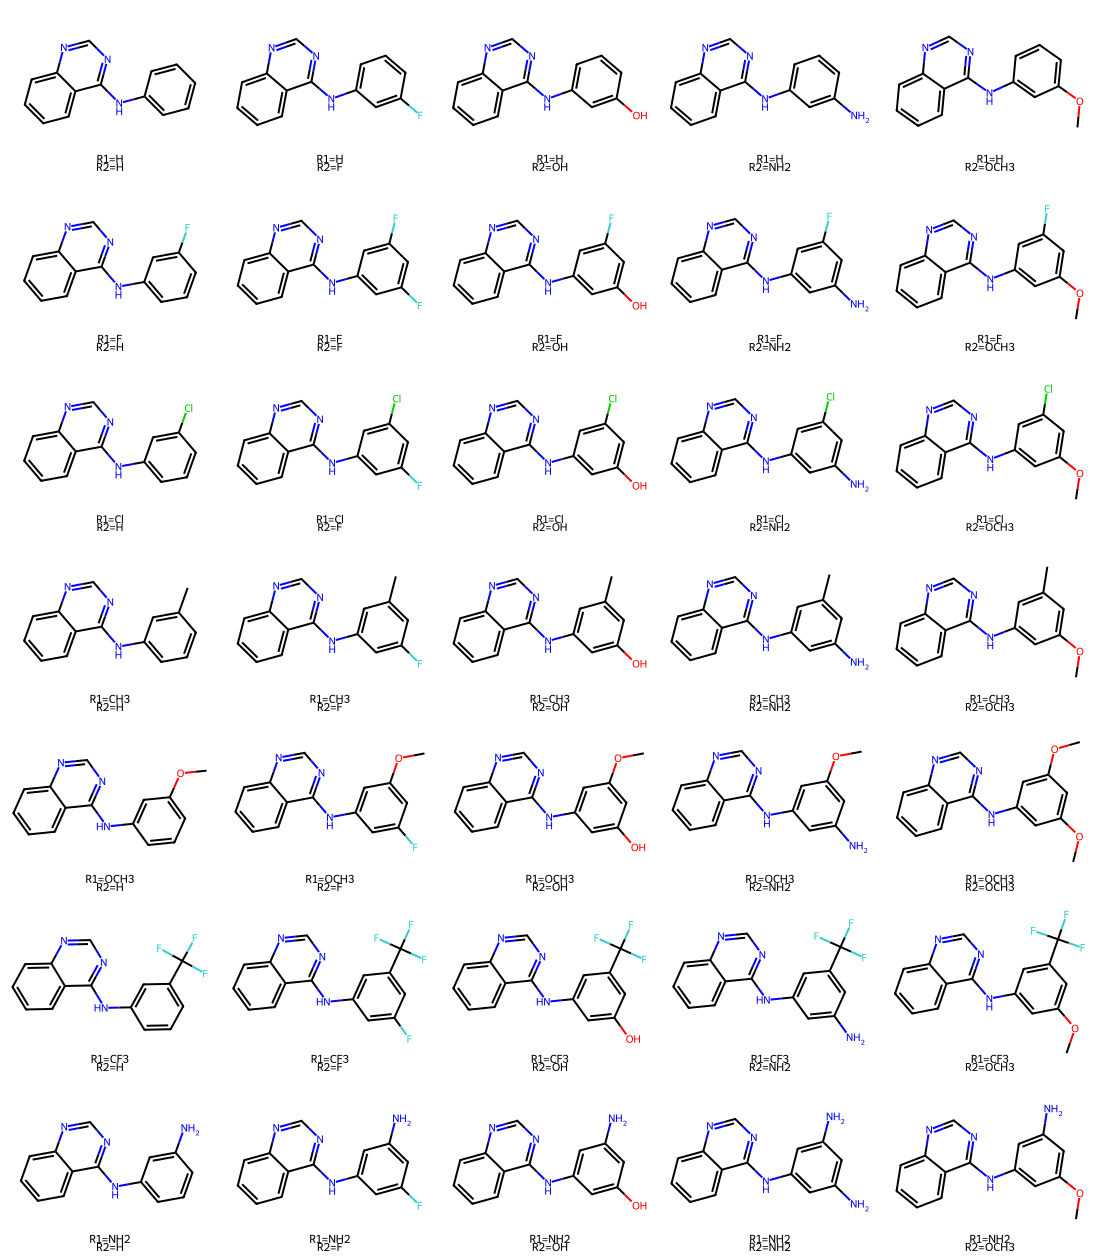

In [4]:
#@title 1-2. 조합 SMILES 생성 & 2D 확인 {display-mode: "form"}
LIGANDS = []
for r1_name, r1_smi in R1_GROUPS.items():
    for r2_name, r2_smi in R2_GROUPS.items():
        smi = CORE_SMILES.replace('[*:1]', r1_smi).replace('[*:2]', r2_smi)
        mol = Chem.MolFromSmiles(smi)
        if mol:
            LIGANDS.append({'name': f'R1={r1_name}_R2={r2_name}', 'R1': r1_name, 'R2': r2_name,
                            'smiles': Chem.MolToSmiles(mol), 'mol': mol})

print(f'{len(LIGANDS)}/{n_total} valid molecules')

# Grid image
mols = [l['mol'] for l in LIGANDS]
legends = [f"R1={l['R1']}\nR2={l['R2']}" for l in LIGANDS]
Draw.MolsToGridImage(mols, legends=legends, molsPerRow=len(R2_GROUPS), subImgSize=(220, 180))


## 2. 타겟 준비 + Box 설정


### PDB 구조 준비

PDB 다운로드 → 정제 → 수소 추가 → Receptor PDBQT 변환.


In [5]:
#@title 2-1. PDB 준비 {display-mode: "form"}
os.chdir(WORK_DIR)
pdb_id = TARGET_PDB.lower()

pdb_path = os.path.join(WORK_DIR, f'{pdb_id}.pdb')
if not os.path.exists(pdb_path):
    urllib.request.urlretrieve(f'https://files.rcsb.org/download/{pdb_id}.pdb', pdb_path)

u = mda.Universe(pdb_path)
prot_sel = u.select_atoms(f'protein and chainID {TARGET_CHAIN}')
lig_sel = u.select_atoms(f'not protein and not nucleic and not resname HOH WAT SOL GOL PEG EDO PG4 DMS ACT BME CL NA MG ZN CA SO4 MN FE CU CO NI CD K BR IOD PO4 NO3 SCN CIT FMT TRS MPD IPA EOH MLI AZI and chainID {TARGET_CHAIN}')
if len(lig_sel) < 3:
    lig_sel = u.select_atoms('not protein and not nucleic and not resname HOH WAT SOL GOL PEG EDO PG4 DMS ACT BME CL NA MG ZN CA SO4 MN FE CU CO NI CD K BR IOD PO4 NO3 SCN CIT FMT TRS MPD IPA EOH MLI AZI')

    # 여러 잔기가 있으면 가장 큰 것(약물)만 선택
    if len(lig_sel) > 0:
        resnames = list(set(lig_sel.resnames))
        if len(resnames) > 1:
            biggest = max(resnames, key=lambda r: len(lig_sel.select_atoms(f'resname {r}')))
            lig_sel = lig_sel.select_atoms(f'resname {biggest}')
            print(f'  Keeping largest ligand: {biggest} ({len(lig_sel)} atoms)')

clean_pdb = os.path.join(WORK_DIR, f'{pdb_id}_clean.pdb')
lig_mol2 = os.path.join(WORK_DIR, f'{pdb_id}_lig.mol2')
prot_sel.write(clean_pdb)
lig_tmp = os.path.join(WORK_DIR, '_lig_tmp.pdb')
lig_sel.write(lig_tmp)
mol = list(pybel.readfile(format='pdb', filename=lig_tmp))[0]
out = pybel.Outputfile(filename=lig_mol2, format='mol2', overwrite=True); out.write(mol); out.close()
os.remove(lig_tmp)

prot_H = os.path.join(WORK_DIR, f'{pdb_id}_clean_H.pdb')
fixer = PDBFixer(filename=clean_pdb)
fixer.findMissingResidues(); fixer.findNonstandardResidues()
fixer.replaceNonstandardResidues(); fixer.removeHeterogens(True)
fixer.findMissingAtoms(); fixer.addMissingAtoms(); fixer.addMissingHydrogens(7.4)
with open(prot_H, 'w') as f: PDBFile.writeFile(fixer.topology, fixer.positions, f)

rec_qt = os.path.join(WORK_DIR, f'{pdb_id}_rec.pdbqt')
mol = list(pybel.readfile(format='pdb', filename=prot_H))[0]
out = pybel.Outputfile(filename=rec_qt+'.tmp', format='pdbqt', overwrite=True); out.write(mol); out.close()
with open(rec_qt+'.tmp') as f: raw = f.readlines()
with open(rec_qt, 'w') as f:
    for l in raw:
        if not l.startswith(('ROOT','ENDROOT','BRANCH','ENDBRANCH','TORSDOF')): f.write(l)
os.remove(rec_qt+'.tmp')

print(f'Receptor: {rec_qt}')


Receptor: /content/sar_matrix/6nzp_rec.pdbqt


### Docking Box 설정

도킹 탐색 공간을 auto/residue/manual 중 선택하여 설정합니다.

**설정값** (2-2. Box 설정):

| 변수 | 기본값 | 타입 | 설명 |
|------|--------|------|------|
| `BOX_METHOD` | `auto` | 선택: auto/residue/manual | 도킹 박스 설정 방식 |
| `RESIDUE_LIST` | `790, 858, 855` | 문자열 | 박스 중심 잔기 번호 (쉼표 구분) |
| `MANUAL_CENTER` | `12.5, -3.0, 27.0` | 문자열 | 박스 중심 좌표 (x, y, z) |
| `MANUAL_SIZE` | `25.0, 25.0, 25.0` | 문자열 | 박스 크기 (x, y, z) Å |
| `PADDING` | `7.0` | 숫자 | 도킹 박스 여유 공간 (Å) |


In [6]:
#@title 2-2. Box 설정 {display-mode: "form"}
BOX_METHOD = "auto"  #@param ["auto", "residue", "manual"]
RESIDUE_LIST = "790, 858, 855"  #@param {type:"string"}
MANUAL_CENTER = "12.5, -3.0, 27.0"  #@param {type:"string"}
MANUAL_SIZE = "25.0, 25.0, 25.0"  #@param {type:"string"}
PADDING = 7.0  #@param {type:"number"}

def get_box_from_coords(coords, padding=7.0):
    minC, maxC = coords.min(axis=0), coords.max(axis=0)
    return (
        {'x': float((maxC[0]+minC[0])/2), 'y': float((maxC[1]+minC[1])/2), 'z': float((maxC[2]+minC[2])/2)},
        {'x': float(maxC[0]-minC[0]+2*padding), 'y': float(maxC[1]-minC[1]+2*padding), 'z': float(maxC[2]-minC[2]+2*padding)}
    )

if BOX_METHOD == "auto":
    center, size = get_box_from_coords(mda.Universe(lig_mol2).atoms.positions, PADDING)
elif BOX_METHOD == "residue":
    res_nums = [int(r.strip()) for r in RESIDUE_LIST.split(',')]
    ref = mda.Universe(prot_H)
    sel = ref.select_atoms(' or '.join([f'resid {r}' for r in res_nums]))
    center, size = get_box_from_coords(sel.positions, PADDING)
elif BOX_METHOD == "manual":
    cx,cy,cz = [float(v) for v in MANUAL_CENTER.split(',')]
    sx,sy,sz = [float(v) for v in MANUAL_SIZE.split(',')]
    center, size = {'x':cx,'y':cy,'z':cz}, {'x':sx,'y':sy,'z':sz}

print(f'Center: ({center["x"]:.1f}, {center["y"]:.1f}, {center["z"]:.1f})')
print(f'Size:   ({size["x"]:.1f}, {size["y"]:.1f}, {size["z"]:.1f})')


Center: (12.8, -3.1, 27.1)
Size:   (26.5, 24.1, 25.2)


### Box 3D 시각화

Box가 결합 부위를 감싸는지 3D로 확인합니다.


In [7]:
#@title 2-3. Box 3D 시각화 {display-mode: "form"}
view = py3Dmol.view(width=800, height=600)
with open(prot_H) as f: view.addModel(f.read(), 'pdb')
view.setStyle({'model': 0}, {'cartoon': {'color': 'white', 'opacity': 0.6}})
with open(lig_mol2) as f: view.addModel(f.read(), 'mol2')
view.setStyle({'model': 1}, {'stick': {'color': 'green', 'radius': 0.2}})
view.addBox({
    'center': {'x': center['x'], 'y': center['y'], 'z': center['z']},
    'dimensions': {'w': size['x'], 'h': size['y'], 'd': size['z']},
    'color': 'blue', 'opacity': 0.15
})
print('Box가 리간드를 감싸는지 확인하세요.')
view.zoomTo()
view.show()


Box가 리간드를 감싸는지 확인하세요.


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 3. R1 × R2 전체 도킹


### R1×R2 전체 조합 도킹

모든 R1×R2 조합을 smina로 도킹합니다.
각 화합물은 SMILES → 3D → PDBQT → 도킹 → SDF 순으로 처리됩니다.

**설정값** (3-1. 전체 조합 도킹):

| 변수 | 기본값 | 타입 | 설명 |
|------|--------|------|------|
| `EXHAUSTIVENESS` | `8` | 정수 | 도킹 탐색 깊이 (높을수록 정확, 느림) |
| `N_POSES` | `5` | 정수 | 생성할 도킹 포즈 수 |
| `N_CPUS` | `0` | 정수 | CPU 코어 수 (0=자동) |


In [8]:
#@title 3-1. 전체 조합 도킹 {display-mode: "form"}
EXHAUSTIVENESS = 8   #@param {type:"integer"}
N_POSES = 5          #@param {type:"integer"}
N_CPUS = 0           #@param {type:"integer"}

smina = os.path.join(BIN_DIR, 'smina')
results = []
t0 = time.time()

for i, lig in enumerate(LIGANDS):
    name = lig['name']
    print(f'[{i+1}/{len(LIGANDS)}] {name}...', end=' ', flush=True)

    mol = Chem.AddHs(lig['mol'])
    AllChem.EmbedMolecule(mol, randomSeed=42)
    AllChem.MMFFOptimizeMolecule(mol)

    # Ligand SDF
    lig_sdf = os.path.join(WORK_DIR, f'{name}.sdf')
    writer = Chem.SDWriter(lig_sdf)
    writer.write(mol)
    writer.close()

    # Docking
    sdf_out = os.path.join(WORK_DIR, f'{name}_docked.sdf')
    subprocess.run([
        smina, '-r', rec_qt, '-l', lig_sdf, '-o', sdf_out,
        '--center_x', str(center['x']), '--center_y', str(center['y']), '--center_z', str(center['z']),
        '--size_x', str(size['x']), '--size_y', str(size['y']), '--size_z', str(size['z']),
        '--exhaustiveness', str(EXHAUSTIVENESS), '--num_modes', str(N_POSES),
        '--cpu', str(N_CPUS),
    ], stdout=None, stderr=None)

    score = None
    if os.path.exists(sdf_out) and os.path.getsize(sdf_out) > 0:
        suppl = list(Chem.SDMolSupplier(sdf_out, removeHs=False))
        scores = []
        for pose_mol in suppl:
            if pose_mol is None: continue
            p = pose_mol.GetPropsAsDict()
            if 'minimizedAffinity' in p:
                try: scores.append(float(p['minimizedAffinity']))
                except: pass
        if scores:
            score = min(scores)

    ha = mol.GetNumHeavyAtoms()
    results.append({
        'Name': name, 'R1': lig['R1'], 'R2': lig['R2'], 'SMILES': lig['smiles'],
        'Score': round(score, 2) if score else None,
        'HA': ha,
        'LE': round(-score / ha, 3) if score and ha > 0 else None,
        'SDF': sdf_out,
    })
    print(f'{score:.2f}' if score else 'FAILED')

elapsed = time.time() - t0
print(f'\n=== {len([r for r in results if r["Score"]])} / {len(LIGANDS)} docked in {elapsed:.0f}s ===')

[1/35] R1=H_R2=H... -7.63
[2/35] R1=H_R2=F... 

[01:54:48] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[01:54:48] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[01:54:48] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[01:54:48] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[01:54:48] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.


-7.88
[3/35] R1=H_R2=OH... 

[01:55:11] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[01:55:11] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[01:55:11] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[01:55:11] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[01:55:11] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.


-7.95
[4/35] R1=H_R2=NH2... 

...

[02:09:54] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[02:09:54] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[02:09:54] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[02:09:54] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[02:09:54] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.


-8.28
[35/35] R1=NH2_R2=OCH3... 

[02:10:20] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[02:10:20] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[02:10:20] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[02:10:20] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[02:10:20] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.


-8.30

=== 35 / 35 docked in 984s ===


[02:10:51] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[02:10:51] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[02:10:51] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[02:10:51] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[02:10:51] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.


## 4. SAR Matrix


### SAR Matrix 히트맵

R1(행) × R2(열) 형태의 매트릭스로 도킹 스코어를 히트맵으로 시각화합니다.
- **초록**: 강한 결합 (좋은 스코어)
- **빨강**: 약한 결합

오른쪽은 Ligand Efficiency 매트릭스입니다.


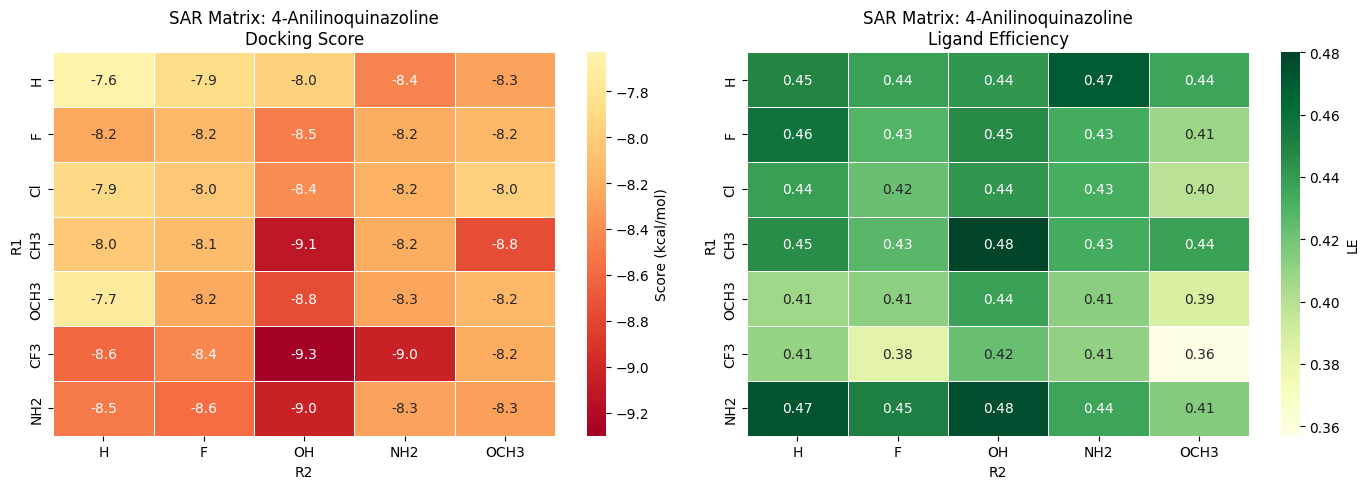


=== Score Matrix ===
R2      H    F   OH  NH2  OCH3
R1                            
H    -7.6 -7.9 -8.0 -8.4  -8.3
F    -8.2 -8.2 -8.5 -8.2  -8.2
Cl   -7.9 -8.0 -8.4 -8.2  -8.0
CH3  -8.0 -8.1 -9.1 -8.2  -8.8
OCH3 -7.7 -8.2 -8.8 -8.3  -8.2
CF3  -8.6 -8.4 -9.3 -9.0  -8.2
NH2  -8.5 -8.6 -9.0 -8.3  -8.3

Best: R1=CF3, R2=OH → -9.30 kcal/mol, LE=0.423


In [9]:
#@title 4-1. SAR Matrix 히트맵 {display-mode: "form"}
df = pd.DataFrame(results)

# Score matrix
matrix = df.pivot_table(index='R1', columns='R2', values='Score', aggfunc='first')
r1_order = [k for k in R1_GROUPS if k in matrix.index]
r2_order = [k for k in R2_GROUPS if k in matrix.columns]
matrix = matrix.loc[r1_order, r2_order]

# LE matrix
le_matrix = df.pivot_table(index='R1', columns='R2', values='LE', aggfunc='first')
le_matrix = le_matrix.loc[r1_order, r2_order]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(matrix, annot=True, fmt='.1f', cmap='RdYlGn', center=-7.5,
            linewidths=0.5, ax=axes[0], cbar_kws={'label': 'Score (kcal/mol)'})
axes[0].set_title(f'SAR Matrix: {CORE_NAME}\nDocking Score')
axes[0].set_ylabel('R1'); axes[0].set_xlabel('R2')

sns.heatmap(le_matrix, annot=True, fmt='.2f', cmap='YlGn',
            linewidths=0.5, ax=axes[1], cbar_kws={'label': 'LE'})
axes[1].set_title(f'SAR Matrix: {CORE_NAME}\nLigand Efficiency')
axes[1].set_ylabel('R1'); axes[1].set_xlabel('R2')

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'sar_matrix_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\n=== Score Matrix ===')
print(matrix.to_string(float_format='%.1f'))
best = df.dropna(subset=['Score']).sort_values('Score').iloc[0]
print(f'\nBest: R1={best["R1"]}, R2={best["R2"]} → {best["Score"]:.2f} kcal/mol, LE={best["LE"]:.3f}')


### R1 / R2 개별 효과

각 R-group이 스코어에 미치는 평균 효과를 분석합니다.
어떤 치환체가 스코어를 높이는지, 낮추는지 한눈에 파악할 수 있습니다.


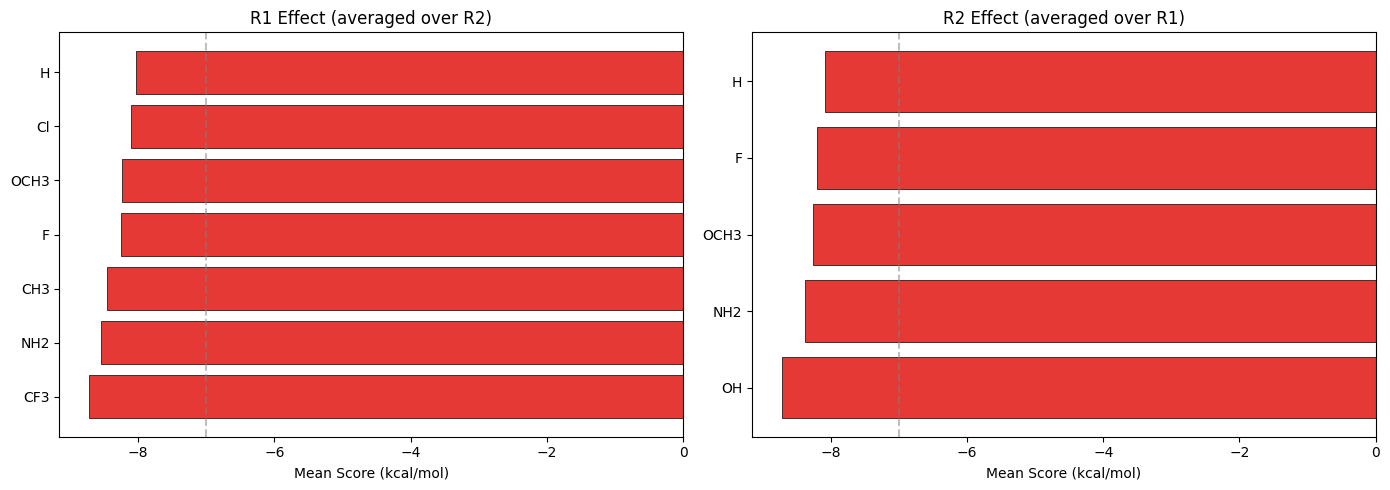

In [10]:
#@title 4-2. R1 / R2 개별 효과 {display-mode: "form"}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

r1_mean = matrix.mean(axis=1).sort_values()
colors = ['#E53935' if v < -8 else '#43A047' if v < -7 else '#FFB300' for v in r1_mean]
axes[0].barh(r1_mean.index, r1_mean.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Mean Score (kcal/mol)')
axes[0].set_title('R1 Effect (averaged over R2)')
axes[0].axvline(x=-7.0, color='gray', linestyle='--', alpha=0.5)

r2_mean = matrix.mean(axis=0).sort_values()
colors = ['#E53935' if v < -8 else '#43A047' if v < -7 else '#FFB300' for v in r2_mean]
axes[1].barh(r2_mean.index, r2_mean.values, color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('Mean Score (kcal/mol)')
axes[1].set_title('R2 Effect (averaged over R1)')
axes[1].axvline(x=-7.0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


### Additivity 체크 (시너지/길항)

R1과 R2의 효과가 독립적(additive)인지 분석합니다:
- **Residual ≈ 0**: 독립적 (R1, R2 효과가 단순 합산)
- **Residual < -0.5**: 시너지 (조합이 예상보다 좋음)
- **Residual > +0.5**: 길항 (조합이 예상보다 나쁨)

시너지/길항 조합은 SAR의 핵심 발견입니다.


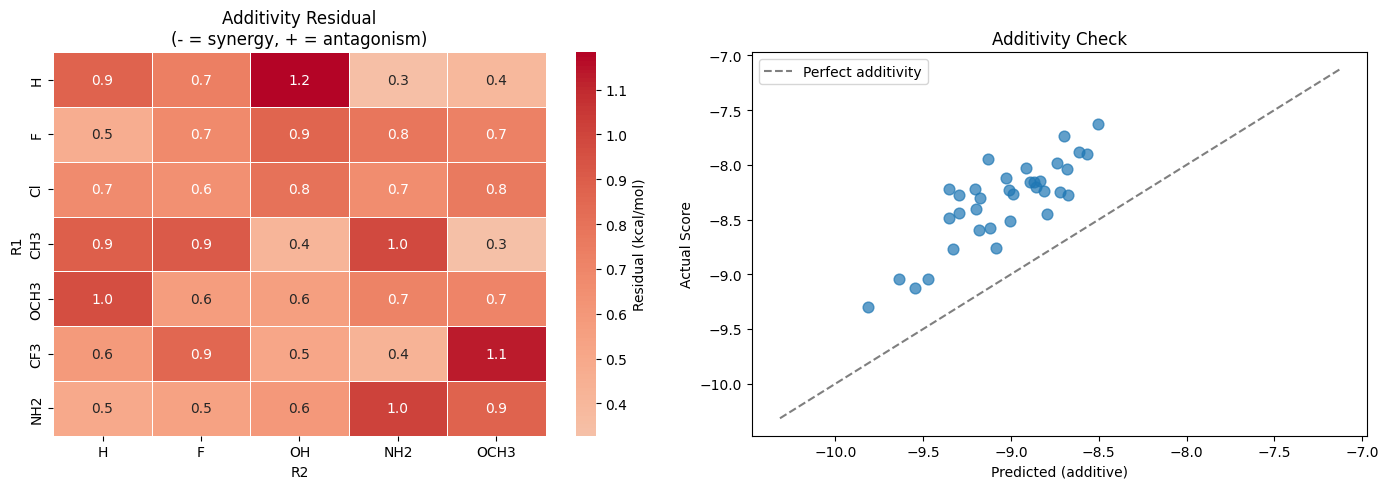

Non-additive combinations (|residual| > 0.5):
  R1=H, R2=H: +0.9 (ANTAGONISM)
  R1=H, R2=F: +0.7 (ANTAGONISM)
  R1=H, R2=OH: +1.2 (ANTAGONISM)
  R1=F, R2=F: +0.7 (ANTAGONISM)
  R1=F, R2=OH: +0.9 (ANTAGONISM)
  R1=F, R2=NH2: +0.8 (ANTAGONISM)
  R1=F, R2=OCH3: +0.7 (ANTAGONISM)
  R1=Cl, R2=H: +0.7 (ANTAGONISM)
  R1=Cl, R2=F: +0.6 (ANTAGONISM)
  R1=Cl, R2=OH: +0.8 (ANTAGONISM)
  R1=Cl, R2=NH2: +0.7 (ANTAGONISM)
  R1=Cl, R2=OCH3: +0.8 (ANTAGONISM)
  R1=CH3, R2=H: +0.9 (ANTAGONISM)
  R1=CH3, R2=F: +0.9 (ANTAGONISM)
  R1=CH3, R2=NH2: +1.0 (ANTAGONISM)
  R1=OCH3, R2=H: +1.0 (ANTAGONISM)
  R1=OCH3, R2=F: +0.6 (ANTAGONISM)
  R1=OCH3, R2=OH: +0.6 (ANTAGONISM)
  R1=OCH3, R2=NH2: +0.7 (ANTAGONISM)
  R1=OCH3, R2=OCH3: +0.7 (ANTAGONISM)
  R1=CF3, R2=H: +0.6 (ANTAGONISM)
  R1=CF3, R2=F: +0.9 (ANTAGONISM)
  R1=CF3, R2=OH: +0.5 (ANTAGONISM)
  R1=CF3, R2=OCH3: +1.1 (ANTAGONISM)
  R1=NH2, R2=F: +0.5 (ANTAGONISM)
  R1=NH2, R2=OH: +0.6 (ANTAGONISM)
  R1=NH2, R2=NH2: +1.0 (ANTAGONISM)
  R1=NH2, R2=OCH3: +0.

In [11]:
#@title 4-3. Additivity 체크 (시너지/길항) {display-mode: "form"}
baseline = matrix.loc['H', 'H'] if 'H' in matrix.index and 'H' in matrix.columns else matrix.values[~np.isnan(matrix.values)].mean()
r1_eff = matrix.mean(axis=1) - baseline
r2_eff = matrix.mean(axis=0) - baseline

predicted = pd.DataFrame(
    [[baseline + r1_eff[r1] + r2_eff[r2] for r2 in r2_order] for r1 in r1_order],
    index=r1_order, columns=r2_order
)
residual = matrix - predicted

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(residual, annot=True, fmt='.1f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=axes[0], cbar_kws={'label': 'Residual (kcal/mol)'})
axes[0].set_title('Additivity Residual\n(- = synergy, + = antagonism)')

axes[1].scatter(predicted.values.flatten(), matrix.values.flatten(), s=60, alpha=0.7)
lim = [min(predicted.values.min(), matrix.values.min())-0.5, max(predicted.values.max(), matrix.values.max())+0.5]
axes[1].plot(lim, lim, 'k--', alpha=0.5, label='Perfect additivity')
axes[1].set_xlabel('Predicted (additive)')
axes[1].set_ylabel('Actual Score')
axes[1].set_title('Additivity Check')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Non-additive combinations (|residual| > 0.5):')
for r1 in r1_order:
    for r2 in r2_order:
        res = residual.loc[r1, r2]
        if abs(res) > 0.5:
            print(f'  R1={r1}, R2={r2}: {res:+.1f} ({"SYNERGY" if res < 0 else "ANTAGONISM"})')


## 5. 내보내기


### 결과 내보내기

CSV 매트릭스 + SDF (DataWarrior) + PyMOL 스크립트를 저장합니다.


In [12]:
#@title 5-1. 결과 내보내기 {display-mode: "form"}
import shutil

matrix.to_csv(os.path.join(WORK_DIR, 'sar_matrix.csv'))
le_matrix.to_csv(os.path.join(WORK_DIR, 'sar_le_matrix.csv'))
df.drop(columns=['SDF','mol'], errors='ignore').to_csv(os.path.join(WORK_DIR, 'sar_table.csv'), index=False)
print('CSV files saved.')

# SDF
combined_sdf = os.path.join(WORK_DIR, 'sar_matrix.sdf')
writer = Chem.SDWriter(combined_sdf)
for _, row in df.iterrows():
    sdf_file = row.get('SDF', '')
    if sdf_file and os.path.exists(sdf_file):
        suppl = Chem.SDMolSupplier(sdf_file, removeHs=False, sanitize=False)
        if suppl and suppl[0]:
            mol = suppl[0]
            for prop in ['Name','R1','R2','Score','LE']:
                mol.SetProp(prop, str(row.get(prop, '')))
            writer.write(mol)
writer.close()
print(f'SDF: {combined_sdf}')

# PyMOL
pml = os.path.join(WORK_DIR, 'sar_matrix_pymol.pml')
top5 = df.dropna(subset=['Score']).nsmallest(5, 'Score')
with open(pml, 'w') as f:
    f.write('reinitialize\nbg_color white\n\n')
    f.write(f'load {prot_H}, protein\nshow cartoon, protein\ncolor white, protein\n\n')
    for i, (_, row) in enumerate(top5.iterrows()):
        c = ['green','cyan','yellow','salmon','orange'][i%5]
        name = row['Name'].replace('=','').replace(' ','_')
        f.write(f'load {row["SDF"]}, {name}\nset all_states, 0\nframe 1\nshow sticks, {name}\ncolor {c}, {name}\n\n')
    f.write(f'select pocket, protein within 5 of {top5.iloc[0]["Name"].replace("=","").replace(" ","_")}\nshow sticks, pocket\n')
    f.write(f'zoom {top5.iloc[0]["Name"].replace("=","").replace(" ","_")}, 8\n')
print(f'PyMOL: {pml}')

# Zip
zip_path = os.path.join(os.path.dirname(WORK_DIR), f'{TARGET_PDB}_sar_matrix')

# 단백질 PDB + 도킹 포즈를 뷰어용 폴더에 복사
import glob as _glob
results_dir = os.path.join(WORK_DIR, 'results_for_viewer')
os.makedirs(results_dir, exist_ok=True)
shutil.copy2(prot_H, os.path.join(results_dir, os.path.basename(prot_H)))
for _sdf in _glob.glob(os.path.join(WORK_DIR, '*_docked.sdf')):
    shutil.copy2(_sdf, results_dir)
print(f'뷰어용 파일: {results_dir}/')
print('  PyMOL/ChimeraX: protein.pdb + *_docked.sdf 를 함께 열기')

shutil.make_archive(zip_path, 'zip', WORK_DIR)
print(f'\nArchive: {zip_path}.zip')
try:
    from google.colab import files
    files.download(f'{zip_path}.zip')
except ImportError:
    print(f'Results at: {WORK_DIR}')


CSV files saved.
SDF: /content/sar_matrix/sar_matrix.sdf
PyMOL: /content/sar_matrix/sar_matrix_pymol.pml
뷰어용 파일: /content/sar_matrix/results_for_viewer/
  PyMOL/ChimeraX: protein.pdb + *_docked.sdf 를 함께 열기

Archive: /content/6nzp_sar_matrix.zip


[02:10:54] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[02:10:54] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[02:10:54] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[02:10:54] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[02:10:54] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[02:10:54] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[02:10:54] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[02:10:54] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[02:10:54] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>